# 07 – Car Parts Segmentation Expanded-Data Training

## Purpose

This notebook trains and evaluates YOLO11n-seg using the current and external car-parts training datasets. It also records the class-definition mismatch discovered between the data sources.

## 1. Setup

In [4]:
%pip install -q ultralytics==8.4.138

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.5 MB/s eta 0:00:00


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [35]:
from pathlib import Path
from zipfile import ZipFile
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from PIL import Image
import json
import random
import shutil

import pandas as pd
import yaml

from ultralytics import YOLO

## 2. Configuration and Paths

In [18]:
CURRENT_DATA_ZIP = Path(
    "/content/drive/MyDrive/data/carparts-seg-processed.zip"
)

EXTERNAL_DATA_ZIP = Path(
    "/content/drive/MyDrive/data/external/hitl-carparts-processed.zip"
)

WORK_DIR = Path("/content/data")
CURRENT_DATA_DIR = WORK_DIR / "current-carparts"
EXTERNAL_DATA_DIR = WORK_DIR / "external-carparts"
EXPANDED_DATA_DIR = WORK_DIR / "carparts-expanded"

RUNS_DIR = Path(
    "/content/drive/MyDrive/qaddir-training-results"
)

MODEL_WEIGHTS = "yolo11n-seg.pt"
RUN_NAME = "carparts_yolo11n_expanded"

IMAGE_SIZE = 640
EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 8
WORKERS = 2
DEVICE = 0
SEED = 42

## 3. Data Loading

In [19]:
if CURRENT_DATA_DIR.exists():
    shutil.rmtree(CURRENT_DATA_DIR)

if EXTERNAL_DATA_DIR.exists():
    shutil.rmtree(EXTERNAL_DATA_DIR)

CURRENT_DATA_DIR.mkdir(parents=True)
EXTERNAL_DATA_DIR.mkdir(parents=True)

with ZipFile(CURRENT_DATA_ZIP, "r") as zip_file:
    zip_file.extractall(CURRENT_DATA_DIR)

with ZipFile(EXTERNAL_DATA_ZIP, "r") as zip_file:
    zip_file.extractall(EXTERNAL_DATA_DIR)

print("Current dataset extracted.")
print("External dataset extracted.")

Current dataset extracted.
External dataset extracted.


In [20]:
CURRENT_ROOT = CURRENT_DATA_DIR / "carparts-seg-processed"
EXTERNAL_ROOT = EXTERNAL_DATA_DIR

CURRENT_YAML = CURRENT_ROOT / "carparts-seg-processed.yaml"
EXTERNAL_YAML = EXTERNAL_ROOT / "hitl-carparts.yaml"

if not CURRENT_YAML.exists():
    raise FileNotFoundError(f"Current YAML not found: {CURRENT_YAML}")

if not EXTERNAL_YAML.exists():
    raise FileNotFoundError(f"External YAML not found: {EXTERNAL_YAML}")

with CURRENT_YAML.open("r") as yaml_file:
    current_config = yaml.safe_load(yaml_file)

with EXTERNAL_YAML.open("r") as yaml_file:
    external_config = yaml.safe_load(yaml_file)

print("Current YAML:", CURRENT_YAML)
print("External YAML:", EXTERNAL_YAML)
print("Current classes:", len(current_config["names"]))
print("External classes:", len(external_config["names"]))

Current YAML: /content/data/current-carparts/carparts-seg-processed/carparts-seg-processed.yaml
External YAML: /content/data/external-carparts/hitl-carparts.yaml
Current classes: 13
External classes: 13


## 4. Data Validation

In [21]:
current_classes = current_config["names"]
external_classes = external_config["names"]

if isinstance(current_classes, dict):
    current_classes = list(current_classes.values())

if isinstance(external_classes, dict):
    external_classes = list(external_classes.values())

class_comparison_df = pd.DataFrame({
    "Class ID": range(len(current_classes)),
    "Current Dataset": current_classes,
    "External Dataset": external_classes
})

display(class_comparison_df)

if current_classes != external_classes:
    raise ValueError(
        "Class names or class order do not match."
    )

,Class ID,Current Dataset,External Dataset
0,0,back_bumper,back_bumper
1,1,back_door,back_door
2,2,back_glass,back_glass
3,3,back_light,back_light
4,4,front_bumper,front_bumper
5,5,front_door,front_door
6,6,front_glass,front_glass
7,7,front_light,front_light
8,8,hood,hood
9,9,side_mirror,side_mirror


In [22]:
dataset_roots = {
    "Current": CURRENT_ROOT,
    "External": EXTERNAL_ROOT
}

dataset_records = []

for dataset_name, dataset_root in dataset_roots.items():
    for split_name in ["train", "val", "test"]:
        images_dir = dataset_root / "images" / split_name
        labels_dir = dataset_root / "labels" / split_name

        image_files = [
            path
            for path in images_dir.iterdir()
            if path.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]

        label_files = list(labels_dir.glob("*.txt"))

        image_stems = {path.stem for path in image_files}
        label_stems = {path.stem for path in label_files}

        dataset_records.append({
            "Dataset": dataset_name,
            "Split": split_name,
            "Images": len(image_files),
            "Labels": len(label_files),
            "Missing Pairs": len(image_stems ^ label_stems)
        })

dataset_summary_df = pd.DataFrame(dataset_records)

display(dataset_summary_df)

,Dataset,Split,Images,Labels,Missing Pairs
0,Current,train,2571,2571,0
1,Current,val,561,561,0
2,Current,test,554,554,0
3,External,train,698,698,0
4,External,val,150,150,0
5,External,test,150,150,0


## 5. Analysis and Visualization

In [23]:
def count_class_instances(labels_dir):
    counts = [0] * len(current_classes)

    for label_path in labels_dir.glob("*.txt"):
        for line in label_path.read_text().splitlines():
            class_id = int(line.split()[0])
            counts[class_id] += 1

    return counts

In [24]:
current_train_counts = count_class_instances(
    CURRENT_ROOT / "labels" / "train"
)

external_train_counts = count_class_instances(
    EXTERNAL_ROOT / "labels" / "train"
)

training_comparison_df = pd.DataFrame({
    "Class": current_classes,
    "Current Train": current_train_counts,
    "External Train": external_train_counts
})

training_comparison_df["Combined Train"] = (
    training_comparison_df["Current Train"]
    + training_comparison_df["External Train"]
)

display(training_comparison_df)

,Class,Current Train,External Train,Combined Train
0,back_bumper,620,315,935
1,back_door,1242,510,1752
2,back_glass,743,196,939
3,back_light,1694,508,2202
4,front_bumper,1394,490,1884
5,front_door,1334,639,1973
6,front_glass,1471,433,1904
7,front_light,2835,630,3465
8,hood,1480,491,1971
9,side_mirror,683,689,1372


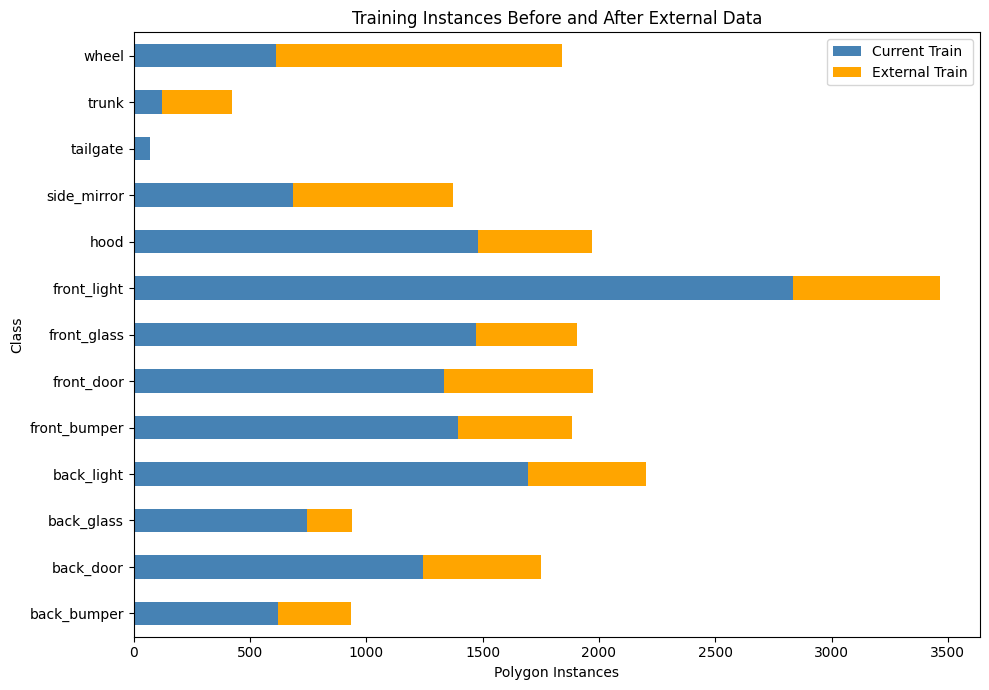

In [25]:
plot_data = training_comparison_df.set_index("Class")[
    ["Current Train", "External Train"]
]

plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    color=["steelblue", "orange"]
)

plt.title("Training Instances Before and After External Data")
plt.xlabel("Polygon Instances")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

## 6. Processing

In [26]:
if EXPANDED_DATA_DIR.exists():
    shutil.rmtree(EXPANDED_DATA_DIR)

shutil.copytree(
    CURRENT_ROOT,
    EXPANDED_DATA_DIR
)

shutil.copytree(
    EXTERNAL_ROOT / "images" / "train",
    EXPANDED_DATA_DIR / "images" / "train",
    dirs_exist_ok=True
)

shutil.copytree(
    EXTERNAL_ROOT / "labels" / "train",
    EXPANDED_DATA_DIR / "labels" / "train",
    dirs_exist_ok=True
)

PosixPath('/content/data/carparts-expanded/labels/train')

In [27]:
validation_rows = []

for split in ["train", "val", "test"]:
    images_dir = EXPANDED_DATA_DIR / "images" / split
    labels_dir = EXPANDED_DATA_DIR / "labels" / split

    image_files = [
        path for path in images_dir.iterdir()
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    label_files = list(labels_dir.glob("*.txt"))

    image_names = {path.stem for path in image_files}
    label_names = {path.stem for path in label_files}

    polygon_count = sum(
        len(path.read_text().splitlines())
        for path in label_files
    )

    empty_labels = sum(
        not path.read_text().strip()
        for path in label_files
    )

    validation_rows.append({
        "Split": split,
        "Images": len(image_files),
        "Labels": len(label_files),
        "Polygons": polygon_count,
        "Missing Pairs": len(image_names ^ label_names),
        "Empty Labels": empty_labels
    })

expanded_validation_df = pd.DataFrame(validation_rows)
display(expanded_validation_df)

,Split,Images,Labels,Polygons,Missing Pairs,Empty Labels
0,train,3269,3269,20727,0,0
1,val,561,561,3096,0,0
2,test,554,554,2967,0,0


In [28]:
train_names = {
    path.stem
    for path in (EXPANDED_DATA_DIR / "images" / "train").iterdir()
}

val_names = {
    path.stem
    for path in (EXPANDED_DATA_DIR / "images" / "val").iterdir()
}

test_names = {
    path.stem
    for path in (EXPANDED_DATA_DIR / "images" / "test").iterdir()
}

print("Train and validation overlap:", len(train_names & val_names))
print("Train and test overlap:", len(train_names & test_names))
print("Validation and test overlap:", len(val_names & test_names))

Train and validation overlap: 0
Train and test overlap: 0
Validation and test overlap: 0


In [29]:
EXPANDED_YAML = EXPANDED_DATA_DIR / "expanded-carparts.yaml"

expanded_config = {
    "path": str(EXPANDED_DATA_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": current_classes
}

with EXPANDED_YAML.open("w") as file:
    yaml.safe_dump(
        expanded_config,
        file,
        sort_keys=False
    )

print("YAML saved to:", EXPANDED_YAML)
print(EXPANDED_YAML.read_text())

YAML saved to: /content/data/carparts-expanded/expanded-carparts.yaml
path: /content/data/carparts-expanded
train: images/train
val: images/val
test: images/test
names:
- back_bumper
- back_door
- back_glass
- back_light
- front_bumper
- front_door
- front_glass
- front_light
- hood
- side_mirror
- tailgate
- trunk
- wheel



In [16]:
model = YOLO(MODEL_WEIGHTS)

training_results = model.train(
    data=str(EXPANDED_YAML),
    project=str(RUNS_DIR),
    name=RUN_NAME,
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    seed=SEED,

    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0
)

New https://pypi.org/project/ultralytics/8.4.144 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/carparts-expanded/expanded-carparts.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

## 7. Results

In [17]:
TRAINING_RUN_DIR = Path(model.trainer.save_dir)
BEST_MODEL_PATH = Path(model.trainer.best)

print("Best model:", BEST_MODEL_PATH)

best_model = YOLO(str(BEST_MODEL_PATH))

validation_results = best_model.val(
    data=str(EXPANDED_YAML),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
    project=str(RUNS_DIR),
    name=f"{TRAINING_RUN_DIR.name}_validation",
    exist_ok=True
)

validation_metrics = {
    name: float(value)
    for name, value in validation_results.results_dict.items()
}

metrics_path = (
    RUNS_DIR
    / f"{TRAINING_RUN_DIR.name}_validation"
    / "validation_metrics.json"
)

metrics_path.write_text(
    json.dumps(validation_metrics, indent=4),
    encoding="utf-8"
)

print("Training results:", TRAINING_RUN_DIR)
print("Validation metrics:", metrics_path)
print(validation_metrics)

Best model: /content/drive/MyDrive/qaddir-training-results/carparts_yolo11n_expanded/weights/best.pt
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,837,103 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1561.8±545.1 MB/s, size: 34.6 KB)
val: Scanning /content/data/carparts-expanded/labels/val.cache... 561 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 561/561 235.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 6.3it/s 11.3s
                   all        561       3096      0.865      0.814      0.861      0.676      0.865       0.81      0.862      0.643
           back_bumper        132        132      0.895      0.839      0.917      0.665      0.859      0.803      0.879      0.643
             back_door        245        245      0.836     

In [7]:
ARGS_PATH = Path(
    "/content/drive/MyDrive/qaddir-training-results/"
    "carparts_yolo11n_expanded/args.yaml"
)

with ARGS_PATH.open("r") as file:
    saved_training_args = yaml.safe_load(file)

augmentation_settings = [
    "hsv_h",
    "hsv_s",
    "hsv_v",
    "degrees",
    "translate",
    "scale",
    "shear",
    "perspective",
    "fliplr",
    "flipud",
    "mosaic",
    "mixup",
    "cutmix",
    "copy_paste"
]

settings_rows = []

for setting in augmentation_settings:
    settings_rows.append({
        "Setting": setting,
        "Value": saved_training_args.get(setting)
    })

augmentation_settings_df = pd.DataFrame(settings_rows)
display(augmentation_settings_df)

,Setting,Value
0,hsv_h,0.015
1,hsv_s,0.700
2,hsv_v,0.400
3,degrees,0.000
4,translate,0.000
5,scale,0.000
6,shear,0.000
7,perspective,0.000
8,fliplr,0.000
9,flipud,0.000


**Finding**

The expanded-data model used Ultralytics default HSV color augmentation, while geometric and composition-based augmentations were disabled. Therefore, the observed results represent the combined effect of the external training data and HSV augmentation, rather than the isolated effect of external data alone.

In [8]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Mask Precision",
        "Mask Recall",
        "Mask mAP50",
        "Mask mAP50-95"
    ],
    "Baseline": [
        0.815,
        0.822,
        0.848,
        0.633
    ],
    "Expanded + HSV": [
        0.865,
        0.810,
        0.862,
        0.643
    ]
})

comparison_df["Change"] = (
    comparison_df["Expanded + HSV"]
    - comparison_df["Baseline"]
)

display(comparison_df.round(3))

,Metric,Baseline,Expanded + HSV,Change
0,Mask Precision,0.815,0.865,0.050
1,Mask Recall,0.822,0.810,-0.012
2,Mask mAP50,0.848,0.862,0.014
3,Mask mAP50-95,0.633,0.643,0.010


**Result**

Adding the external data with HSV augmentation increased mask precision and mask mAP, but slightly reduced overall mask recall. The largest concern was the decline in `trunk` mask mAP50–95, despite adding more training instances for this class.

**Trunk and Tailgate Annotation Review**

A visual review compares the current `trunk`, current `tailgate`, and external `trunk` annotations to check whether the class definitions are consistent across data sources.

In [30]:
images_dir = Path("/content/data/carparts-expanded/images/train")
labels_dir = Path("/content/data/carparts-expanded/labels/train")

image_paths = {
    path.stem: path
    for path in images_dir.iterdir()
    if path.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

current_trunk_labels = []
current_tailgate_labels = []
external_trunk_labels = []

for label_path in labels_dir.glob("*.txt"):
    class_ids = [
        int(line.split()[0])
        for line in label_path.read_text().splitlines()
        if line.strip()
    ]

    is_external = label_path.stem.startswith("hitl_")

    if 11 in class_ids:
        if is_external:
            external_trunk_labels.append(label_path)
        else:
            current_trunk_labels.append(label_path)

    if 10 in class_ids and not is_external:
        current_tailgate_labels.append(label_path)

random_generator = random.Random(42)

review_groups = {
    "Current trunk": random_generator.sample(current_trunk_labels, 3),
    "Current tailgate": random_generator.sample(current_tailgate_labels, 3),
    "External trunk": random_generator.sample(external_trunk_labels, 3)
}

for group_name, labels in review_groups.items():
    print(group_name, ":", len(labels))

Current trunk : 3
Current tailgate : 3
External trunk : 3


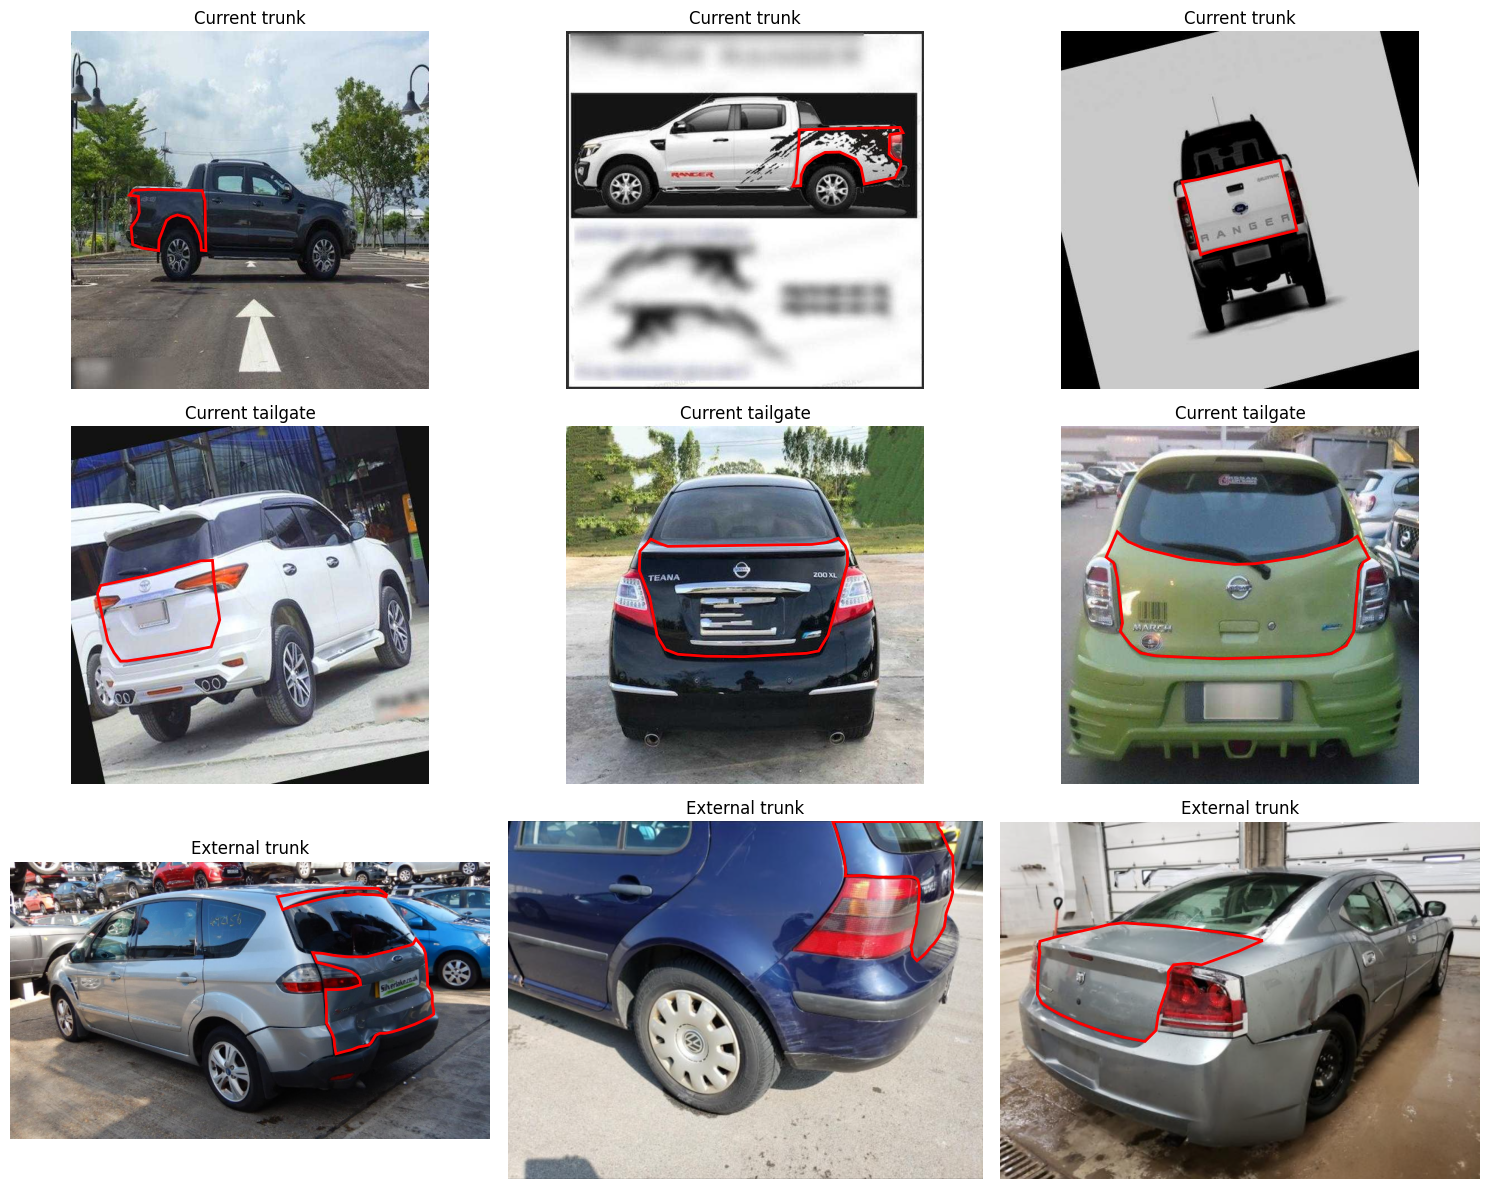

In [36]:
figure, axes = plt.subplots(3, 3, figsize=(15, 12))

group_class_ids = {
    "Current trunk": 11,
    "Current tailgate": 10,
    "External trunk": 11
}

for row, (group_name, label_paths) in enumerate(review_groups.items()):
    target_class_id = group_class_ids[group_name]

    for column, label_path in enumerate(label_paths):
        axis = axes[row, column]
        image_path = image_paths[label_path.stem]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        axis.imshow(image)

        for line in label_path.read_text().splitlines():
            values = line.split()
            class_id = int(values[0])

            if class_id != target_class_id:
                continue

            coordinates = np.array(
                values[1:],
                dtype=float
            ).reshape(-1, 2)

            coordinates[:, 0] *= width
            coordinates[:, 1] *= height

            axis.add_patch(
                Polygon(
                    coordinates,
                    closed=True,
                    fill=False,
                    edgecolor="red",
                    linewidth=2
                )
            )

        axis.set_title(group_name)
        axis.axis("off")

plt.tight_layout()
plt.show()

**Finding**

The annotation review revealed a class-definition mismatch. In the current dataset, `trunk` mainly represents the cargo-bed area of pickup trucks, while `tailgate` represents sedan trunk lids and rear hatch doors. The external `trunk` annotations are visually consistent with the current `tailgate` class rather than the current `trunk` class. This mismatch likely contributed to the decline in `trunk` validation performance.

## 8. Decisions and Next Steps

- The expanded-data model achieved a Mask mAP50–95 of 0.643, compared with 0.633 for the baseline.
- Mask precision improved from 0.815 to 0.865, while mask recall decreased from 0.822 to 0.810.
- The saved configuration confirmed that default HSV augmentation was enabled. Therefore, the result represents the combined effect of external data and HSV augmentation.
- `wheel` and `side_mirror` improved, while `trunk` performance declined.
- Visual annotation review identified a class-definition mismatch: the external `trunk` corresponds to the current `tailgate`, while the current `trunk` mainly represents pickup truck beds.
- The current checkpoint will be preserved as an experimental result, but it will not be selected as the final model yet.
- The next experiment will rename class 10 to `trunk_or_tailgate`, rename class 11 to `truck_bed`, and remap external `trunk` polygons from class 11 to class 10.
- The corrected combined dataset will then be trained with a controlled augmentation configuration.
- The test split remains untouched until the final model is selected.